# Tarea 3 — Vibraciones libres y modos normales
IMEC 4001 — Matemáticas Aplicadas  
Universidad de los Andes · 2026-2

**Estudiante:** Luis Alejandro Rodríguez Cod. 202321287

In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

k = sp.symbols('k', positive=True)

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

## Ejercicio 1a

In [3]:
import sympy as sp
from IPython.display import display, Math

# Matriz de rigidez
K = sp.Matrix([
    [sp.Rational(21, 20), -sp.Rational(1, 20)],
    [-sp.Rational(1, 20), sp.Rational(21, 20)]
])

display(Math(r"\mathbf{K} ="))
display(K)

# Autovalores
display(Math(r"\text{Autovalores } \lambda = \omega^2"))

eigenvalues = K.eigenvals()

for lam in eigenvalues:
    display(Math(fr"\lambda = {sp.latex(lam)}"))
    display(Math(fr"\omega = {sp.latex(sp.sqrt(lam))}"))

# Autovectores
display(Math(r"\text{Autovectores}"))

eigenvectors = K.eigenvects()

for lam, multiplicity, vectors in eigenvectors:

    display(Math(fr"\lambda = {sp.latex(lam)}"))

    for v in vectors:

        display(Math(
            fr"\mathbf{{q}} = {sp.latex(v)}"
        ))

        # Normalización
        v_norm = v / sp.sqrt(v.dot(v))

        display(Math(
            fr"\mathbf{{q}}_{{\mathrm{{normalizado}}}} = "
            fr"{sp.latex(v_norm)}"
        ))

# Matriz modal Q
Q = sp.Matrix.hstack(
    sp.Matrix([1, 1]) / sp.sqrt(2),
    sp.Matrix([1, -1]) / sp.sqrt(2)
)

display(Math(r"\mathbf{Q} ="))
display(Q)

# Verificación de ortonormalidad
display(Math(r"\mathbf{Q}^T\mathbf{Q} ="))
display(Q.T * Q)

<IPython.core.display.Math object>

Matrix([
[21/20, -1/20],
[-1/20, 21/20]])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Matrix([
[sqrt(2)/2,  sqrt(2)/2],
[sqrt(2)/2, -sqrt(2)/2]])

<IPython.core.display.Math object>

Matrix([
[1, 0],
[0, 1]])

## Ejercicio 1b - Completamente a mano

In [4]:
# Matriz [cos(ωt)]

t = sp.symbols('t', real=True)

omega1 = sp.sqrt(eigenvalues[1] if False else 1)
omega2 = sp.sqrt(sp.Rational(11, 10))

cos_omega_t = sp.diag(
    sp.cos(omega1 * t),
    sp.cos(omega2 * t)
)

display(Math(r"\mathbf{[\cos\omega t]} ="))
display(cos_omega_t)

<IPython.core.display.Math object>

Matrix([
[cos(t),                   0],
[     0, cos(sqrt(110)*t/10)]])

## Ejercicio 1c
### c) Solucion y grafica

Para la condicion inicial

$$
u_0 =
\begin{pmatrix}
1\\
0
\end{pmatrix},
$$

la solucion obtenida analiticamente es

$$
u(t)=
\frac{1}{2}
\begin{pmatrix}
\cos(t)+\cos\left(\sqrt{\frac{11}{10}}t\right)\\
\cos(t)-\cos\left(\sqrt{\frac{11}{10}}t\right)
\end{pmatrix}.
$$

Se utiliza Python para evaluar y graficar la solucion en funcion del tiempo.

In [5]:
w1 = 1
w2 = np.sqrt(11 / 10)

u0 = np.array([1, 0])

display(f"w1 = {w1}")
display(f"w2 = {w2:.4f}")
display(f"u0 = {u0}")

'w1 = 1'

'w2 = 1.0488'

'u0 = [1 0]'

In [6]:
def u(t):
    u1 = 0.5 * (np.cos(w1 * t) + np.cos(w2 * t))
    u2 = 0.5 * (np.cos(w1 * t) - np.cos(w2 * t))
    
    return np.array([u1, u2])

In [7]:
t = np.linspace(0, 300, 5000)

U = u(t)

u1 = U[0]
u2 = U[1]

display(f"Numero de puntos: {len(t)}")
display(f"Intervalo: [{t[0]}, {t[-1]}]")

'Numero de puntos: 5000'

'Intervalo: [0.0, 300.0]'

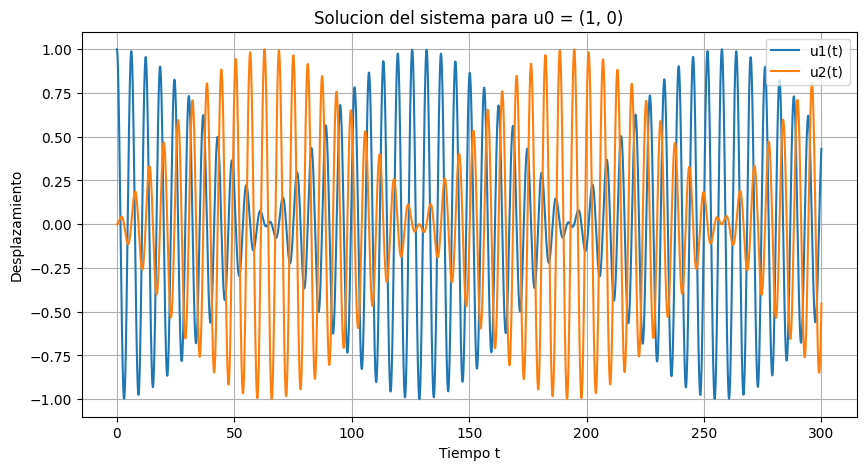

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(t, u1, label="u1(t)")
plt.plot(t, u2, label="u2(t)")

plt.xlabel("Tiempo t")
plt.ylabel("Desplazamiento")
plt.title("Solucion del sistema para u0 = (1, 0)")
plt.grid()
plt.legend()

plt.show()